# Customer Churn Dataset

Dataset de Analítica de Interacción del Cliente y Abandono (Churn)
Un conjunto de 50.000 registros de clientes con 25 atributos que abarcan datos demográficos, patrones de comportamiento, historial de compras y métricas de interacción.

El conjunto de datos recoge interacciones multicanal de clientes a través de plataformas web, móviles, correo electrónico y redes sociales, proporcionando una visión 360° del comportamiento del cliente.
Incluye una variable objetivo binaria (Churned).

- Registros: 50.000
- Atributos: 25
- Variable a clasificar: Binaria (Cliente abandono [1] o no abandono[0])


##### Importacion de datos

In [49]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
pd.set_option('display.max_columns', None) #Para que se vean todas las columnas
churn_data = pd.read_csv("customer_churn.csv")
churn_data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Revision de Tipos, Faltantes y Columnas

In [51]:
#Tipos de dato de cada variable y cantidad de no-nulos por cada una
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

Descriptivos por atributo

In [52]:
# Para las numericas
churn_data.select_dtypes(include='number').agg(['count', 'mean', 'std', 'min', 'max','median']) 

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000
median,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000


Cosas "raras" de los datos:
- Edad minima 5 y maxima 200
- Total_purchases minimo -13?
- 

In [53]:
# hay 30 menores de 18 y 20 mayores de 149, voy a limpiarlos, ya que alguien de 150 es imposible y de 10 años o menos es muy extraño
churn_data.groupby('Age').size()

Age
5.0        16
10.0       14
18.0     2639
19.0      493
20.0      550
         ... 
73.0       27
74.0       11
75.0       45
150.0       9
200.0      11
Length: 62, dtype: int64

In [54]:
# Voy a eliminar los que tienen compras totales negativas (no tiene sentido)
churn_data.groupby('Total_Purchases').size()


Total_Purchases
-13.0     1
-11.7     2
-10.4     1
-10.0     3
-9.1      1
         ..
 118.3    2
 123.5    2
 124.8    1
 127.4    1
 128.7    1
Length: 150, dtype: int64

In [55]:
# Solo conservar edades válidas y cantidades de compra validas
churn_data = churn_data.query("Age >= 18 and Age <= 100 and Total_Purchases >= 0")
print("Filas tras filtrar por edad y compras:", churn_data.shape[0])


Filas tras filtrar por edad y compras: 47418


In [56]:
# Para las categoricas
churn_data.select_dtypes(include='object').describe()

,Gender,Country,City,Signup_Quarter
count,47418,47418,47418,47418
unique,3,8,40,4
top,Female,USA,Houston,Q2
freq,23830,16468,3363,11907


# Algunos Graficos

### Histogramas para categoricas

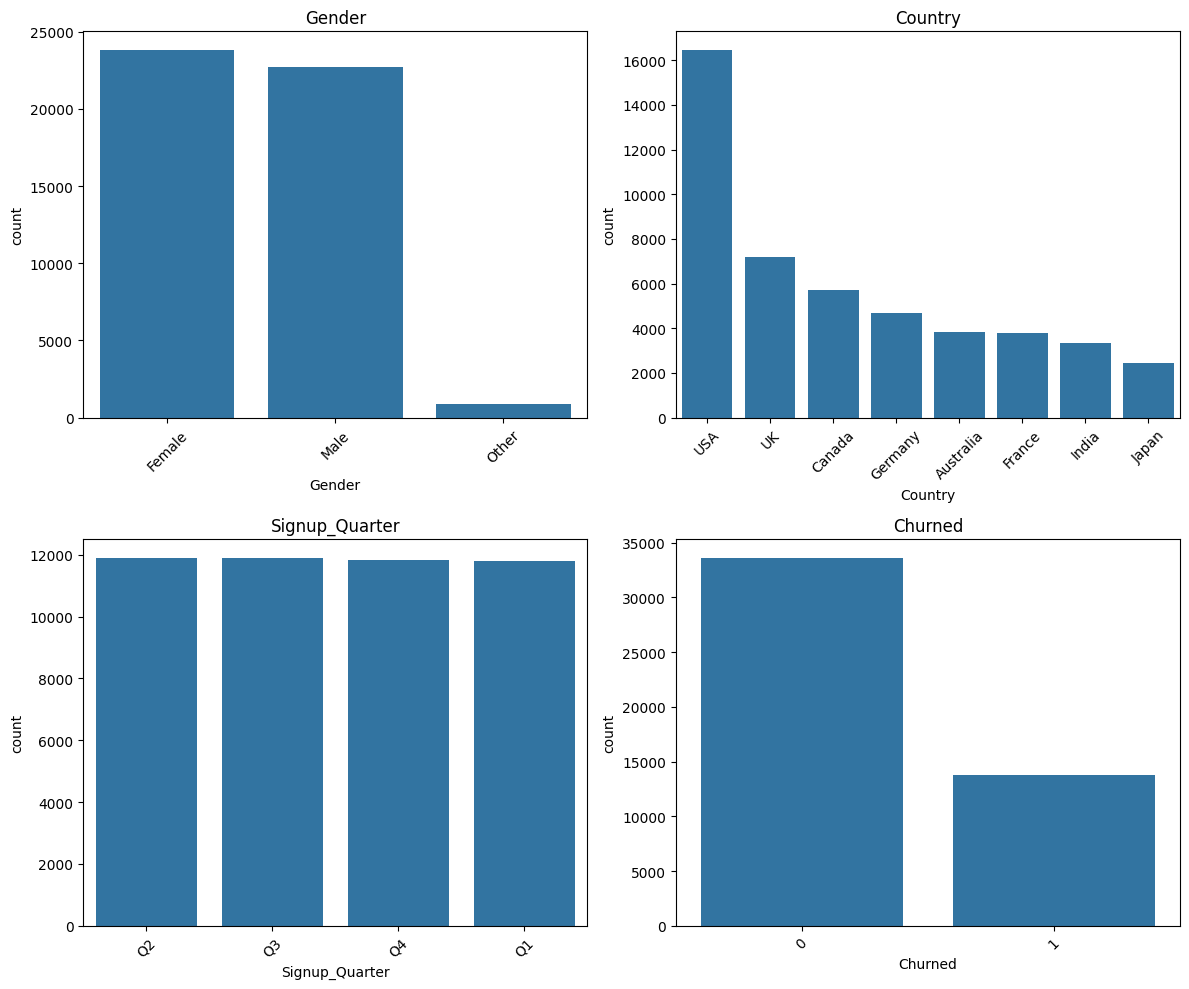

In [57]:

columns_to_plot = ['Gender', 'Country', 'Signup_Quarter','Churned']  

n_cols = 2  # columnas por fila
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols  # filas necesarias

plt.figure(figsize=(n_cols*6, n_rows*5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=churn_data, x=col, order=churn_data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

Se observa desbalanceo entre clases, mayor cantidad de Churned

### Cuantitativas

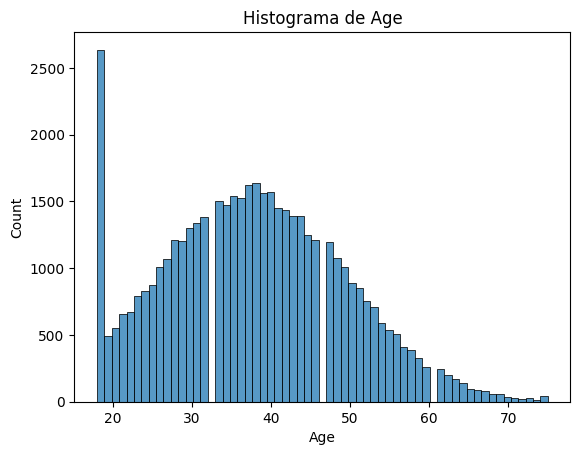

In [58]:
sns.histplot(data=churn_data, x=churn_data.Age)  
plt.title("Histograma de Age")
plt.show()
# Se observan muchas personas de 18 año, con esa salvedad la curva responde a distribucion normal.

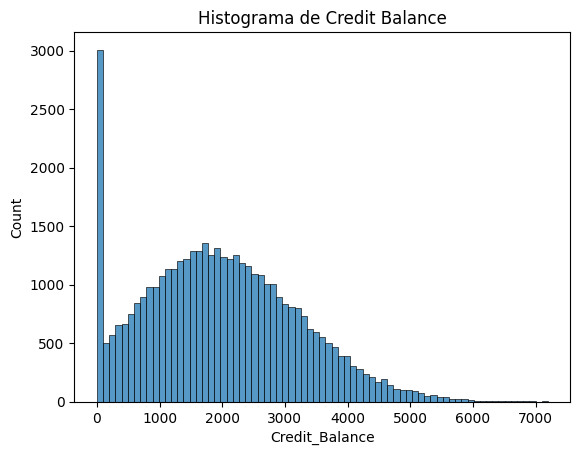

In [59]:
sns.histplot(data=churn_data, x=churn_data.Credit_Balance)  
plt.title("Histograma de Credit Balance")
plt.show()

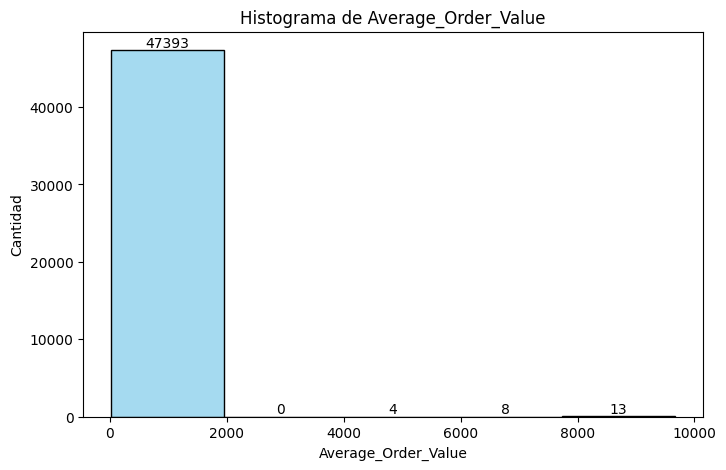

In [60]:
min_val = churn_data.Average_Order_Value.min()
max_val = churn_data.Average_Order_Value.max()

# 5 bins exactos
bins = np.linspace(min_val, max_val, 6)  # 6 puntos → 5 intervalos

# Crear histograma
plt.figure(figsize=(8,5))
ax = sns.histplot(churn_data['Average_Order_Value'], bins=bins, kde=False, stat='count', color='skyblue')

# Agregar cantidad encima de cada barra
for p in ax.patches:
    ax.annotate(
        int(p.get_height()), 
        (p.get_x() + p.get_width()/2., p.get_height()), 
        ha='center', 
        va='bottom'
    )

plt.title("Histograma de Average_Order_Value")
plt.xlabel("Average_Order_Value")
plt.ylabel("Cantidad")
plt.show()


Practicamente todos estan por debajo de los 2000 de promedio de compra, pero de aca no voy a borrar nada ya que esos compradores de grandes numeros pueden ser informacion real y util

# Preparacion de datos previo a entrenamiento

In [61]:
# Ver porcentaje de valores faltantes por columna
churn_data.isnull().mean() * 100


Age                               0.000000
Gender                            0.000000
Country                           0.000000
City                              0.000000
Membership_Years                  0.000000
Login_Frequency                   0.000000
Session_Duration_Avg              6.775908
Pages_Per_Session                 5.985069
Cart_Abandonment_Rate             0.000000
Wishlist_Items                    7.975874
Total_Purchases                   0.000000
Average_Order_Value               0.000000
Days_Since_Last_Purchase          6.031465
Discount_Usage_Rate               7.045848
Returns_Rate                      8.975495
Email_Open_Rate                   5.069805
Customer_Service_Calls            0.335316
Product_Reviews_Written           7.014214
Social_Media_Engagement_Score    12.008098
Mobile_App_Usage                  9.996204
Payment_Method_Diversity          5.019191
Lifetime_Value                    0.000000
Credit_Balance                   10.997933
Churned    

In [62]:
# Para las numericas voy a imputar con la mediana, ya que es mas robusta a outliers

num_cols = churn_data.select_dtypes(include='number').columns

for col in num_cols:
    median_value = churn_data[col].median()
    churn_data[col].fillna(median_value)

# Las categoricas les voy a poner una categoria extra

cat_cols = churn_data.select_dtypes(include='object').columns

for col in cat_cols:
    churn_data[col].fillna("Unknown")

churn_data.isnull().mean() * 100 # ya no hay mas faltantes


Age                               0.000000
Gender                            0.000000
Country                           0.000000
City                              0.000000
Membership_Years                  0.000000
Login_Frequency                   0.000000
Session_Duration_Avg              6.775908
Pages_Per_Session                 5.985069
Cart_Abandonment_Rate             0.000000
Wishlist_Items                    7.975874
Total_Purchases                   0.000000
Average_Order_Value               0.000000
Days_Since_Last_Purchase          6.031465
Discount_Usage_Rate               7.045848
Returns_Rate                      8.975495
Email_Open_Rate                   5.069805
Customer_Service_Calls            0.335316
Product_Reviews_Written           7.014214
Social_Media_Engagement_Score    12.008098
Mobile_App_Usage                  9.996204
Payment_Method_Diversity          5.019191
Lifetime_Value                    0.000000
Credit_Balance                   10.997933
Churned    

separo variables de la target

In [63]:
y = churn_data['Churned']  # 1 si el cliente abandonó, 0 si no
X = churn_data.drop(columns=['Churned'])


Identificar categóricas y numéricas

Codificar categóricas (One-Hot o Label)

In [64]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [65]:
cat_cols = X.select_dtypes(include='object').columns.tolist()  # categóricas
num_cols = X.select_dtypes(include='number').columns.tolist()  # numéricas

# Preprocesador: solo OneHot para categóricas, numéricas tal cual
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

# Aplicar transformación
X_processed_array = preprocessor.fit_transform(X)

# Crear nombres de columnas
columns = list(preprocessor.get_feature_names_out())
# Renombrar numéricas para quitar 'remainder__'
columns = [col.replace('remainder__','') for col in columns]

# Convertir a DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=columns, index=X.index)

print("Columnas procesadas:", X_processed.shape[1])

Columnas procesadas: 71


Dividir train-test

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
# Divido 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.2,         # 20% de los datos para test
    random_state=42,        # semilla para reproducibilidad
    stratify=y              # mantiene la proporción de clases
)

Armado del modelo

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
# Crear el modelo
rf_clf = RandomForestClassifier(
    n_estimators=200,      # número de árboles
    max_depth=10,        # Probe sin limite pero sobreajusta
    random_state=42,
    class_weight='balanced' # ajusta pesos si las clases están desbalanceadas
)

# Entrenar
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [70]:
# Precisión en train y test
print("Accuracy en train:", rf_clf.score(X_train, y_train))
print("Accuracy en test:", rf_clf.score(X_test, y_test))


Accuracy en train: 0.9242631939684716
Accuracy en test: 0.8968789540278364


In [71]:
from sklearn.metrics import classification_report, confusion_matrix


In [72]:

y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.92      0.93      6726
           1       0.81      0.84      0.83      2758

    accuracy                           0.90      9484
   macro avg       0.87      0.88      0.88      9484
weighted avg       0.90      0.90      0.90      9484

[[6181  545]
 [ 433 2325]]
